# 05 — Model Analysis & Candidate Selection

## 1. Objective
The goal of this notebook is to perform comprehensive **model analysis, feature interpretability, generalization diagnostics, and candidate model selection** for heart disease diagnosis prediction.

Key Analysis Deliverables:
1. Compare held-out test metrics and 5-fold cross-validation performance.
2. Analyze generalization gaps ($	ext{Test} - 	ext{CV Mean}$).
3. Extract confusion matrix elements (TN, FP, FN, TP) and compute Recall, Specificity, FNR, and FPR.
4. Extract transformed feature coefficients from **Logistic Regression**.
5. Extract Gini feature importances from **Random Forest**.
6. Compare feature importance rankings across linear and tree-based models.
7. Establish a defensible candidate model selection framework (Primary & Secondary candidates).


## 2. Load Baseline Results & Project Modules
We import analytical modules (`src.data_loader`, `src.train`, `src.model_analysis`) and load baseline results.


In [1]:
import sys
from pathlib import Path

# Locate project root containing src/
root_dir = Path.cwd()
for p in [root_dir] + list(root_dir.parents):
    if (p / 'src' / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import REPORTS_DIR, FIGURES_DIR
from src.data_loader import load_model_data, split_data
from src.train import train_baseline_models
from src.model_analysis import (
    extract_logistic_coefficients,
    extract_tree_feature_importance,
    compare_feature_importance,
    analyze_cv_vs_test,
    analyze_confusion_matrices,
    generate_model_selection_summary,
)

# Load data and fit baseline models
X, y = load_model_data()
X_train, X_test, y_train, y_test = split_data(X, y)
results_df, fitted_pipelines = train_baseline_models(X_train, X_test, y_train, y_test)

print(f"Evaluated {len(results_df)} baseline models across {len(X_train)} training and {len(X_test)} test samples.")


C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

Evaluated 5 baseline models across 734 training and 184 test samples.


## 3. Compare Held-Out Test Set Metrics
Display held-out test performance across Accuracy, Precision, Recall, F1, and ROC-AUC.


In [2]:
test_cols = ["Model", "Test_Accuracy", "Test_Precision", "Test_Recall", "Test_F1", "Test_ROC_AUC"]
results_df[test_cols].sort_values(by="Test_ROC_AUC", ascending=False).reset_index(drop=True)


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Logistic Regression,0.836957,0.846154,0.862745,0.854369,0.927786
1,Support Vector Machine,0.836957,0.833333,0.882353,0.857143,0.911406
2,Random Forest,0.815217,0.826923,0.843137,0.834951,0.911227
3,K-Nearest Neighbors,0.842391,0.841121,0.882353,0.861244,0.899809
4,Decision Tree,0.711957,0.737864,0.745098,0.741463,0.707915


## 4. Compare 5-Fold Cross-Validation Metrics
Display 5-fold Stratified Cross-Validation means and standard deviations computed exclusively on `X_train`.


In [3]:
cv_cols = ["Model", "CV_Accuracy_Mean", "CV_Accuracy_Std", "CV_Precision_Mean", "CV_Recall_Mean", "CV_F1_Mean", "CV_ROC_AUC_Mean"]
results_df[cv_cols].sort_values(by="CV_ROC_AUC_Mean", ascending=False).reset_index(drop=True)


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_ROC_AUC_Mean
0,Logistic Regression,0.816103,0.044612,0.828288,0.847245,0.836922,0.879220
1,Support Vector Machine,0.810642,0.040610,0.816158,0.857121,0.834702,0.866734
2,Random Forest,0.806579,0.044895,0.821119,0.839928,0.829020,0.857835
3,K-Nearest Neighbors,0.798369,0.044815,0.791014,0.869497,0.827502,0.841092
4,Decision Tree,0.707129,0.032971,0.738912,0.726558,0.732259,0.704748


## Error and Generalization Analysis

### 1. Confusion Matrix Summary & Definitions
We evaluate held-out test predictions across all five baseline models to extract true negatives (TN), false positives (FP), false negatives (FN), and true positives (TP).

Key Definitions & Cautious Error Trade-off:
- **False Negatives (FN):** Represent observations belonging to class 1 that were predicted as class 0.
- **False Positives (FP):** Represent observations belonging to class 0 that were predicted as class 1.
- **Sensitivity / Recall:** $	ext{Sensitivity} = \frac{	ext{TP}}{	ext{TP} + 	ext{FN}}$
- **Specificity:** $	ext{Specificity} = \frac{	ext{TN}}{	ext{TN} + 	ext{FP}}$
- **False Negative Rate (FNR):** $	ext{FNR} = \frac{	ext{FN}}{	ext{TP} + 	ext{FN}} = 1 - 	ext{Sensitivity}$
- **False Positive Rate (FPR):** $	ext{FPR} = \frac{	ext{FP}}{	ext{FP} + 	ext{TN}} = 1 - 	ext{Specificity}$

> **CAUTIOUS CLINICAL NOTE:** For a screening-oriented application, false negatives may be particularly consequential; however, the appropriate error trade-off depends on the intended clinical use and requires clinical validation.


In [4]:
cm_df = analyze_confusion_matrices(fitted_pipelines, X_test, y_test)
cm_df


,Model,TN,FP,FN,TP,Recall,Sensitivity,Specificity,False_Negative_Rate,False_Positive_Rate
0,Logistic Regression,66,16,14,88,0.862745,0.862745,0.804878,0.137255,0.195122
1,K-Nearest Neighbors,65,17,12,90,0.882353,0.882353,0.792683,0.117647,0.207317
2,Decision Tree,55,27,26,76,0.745098,0.745098,0.670732,0.254902,0.329268
3,Random Forest,64,18,16,86,0.843137,0.843137,0.780488,0.156863,0.219512
4,Support Vector Machine,64,18,12,90,0.882353,0.882353,0.780488,0.117647,0.219512


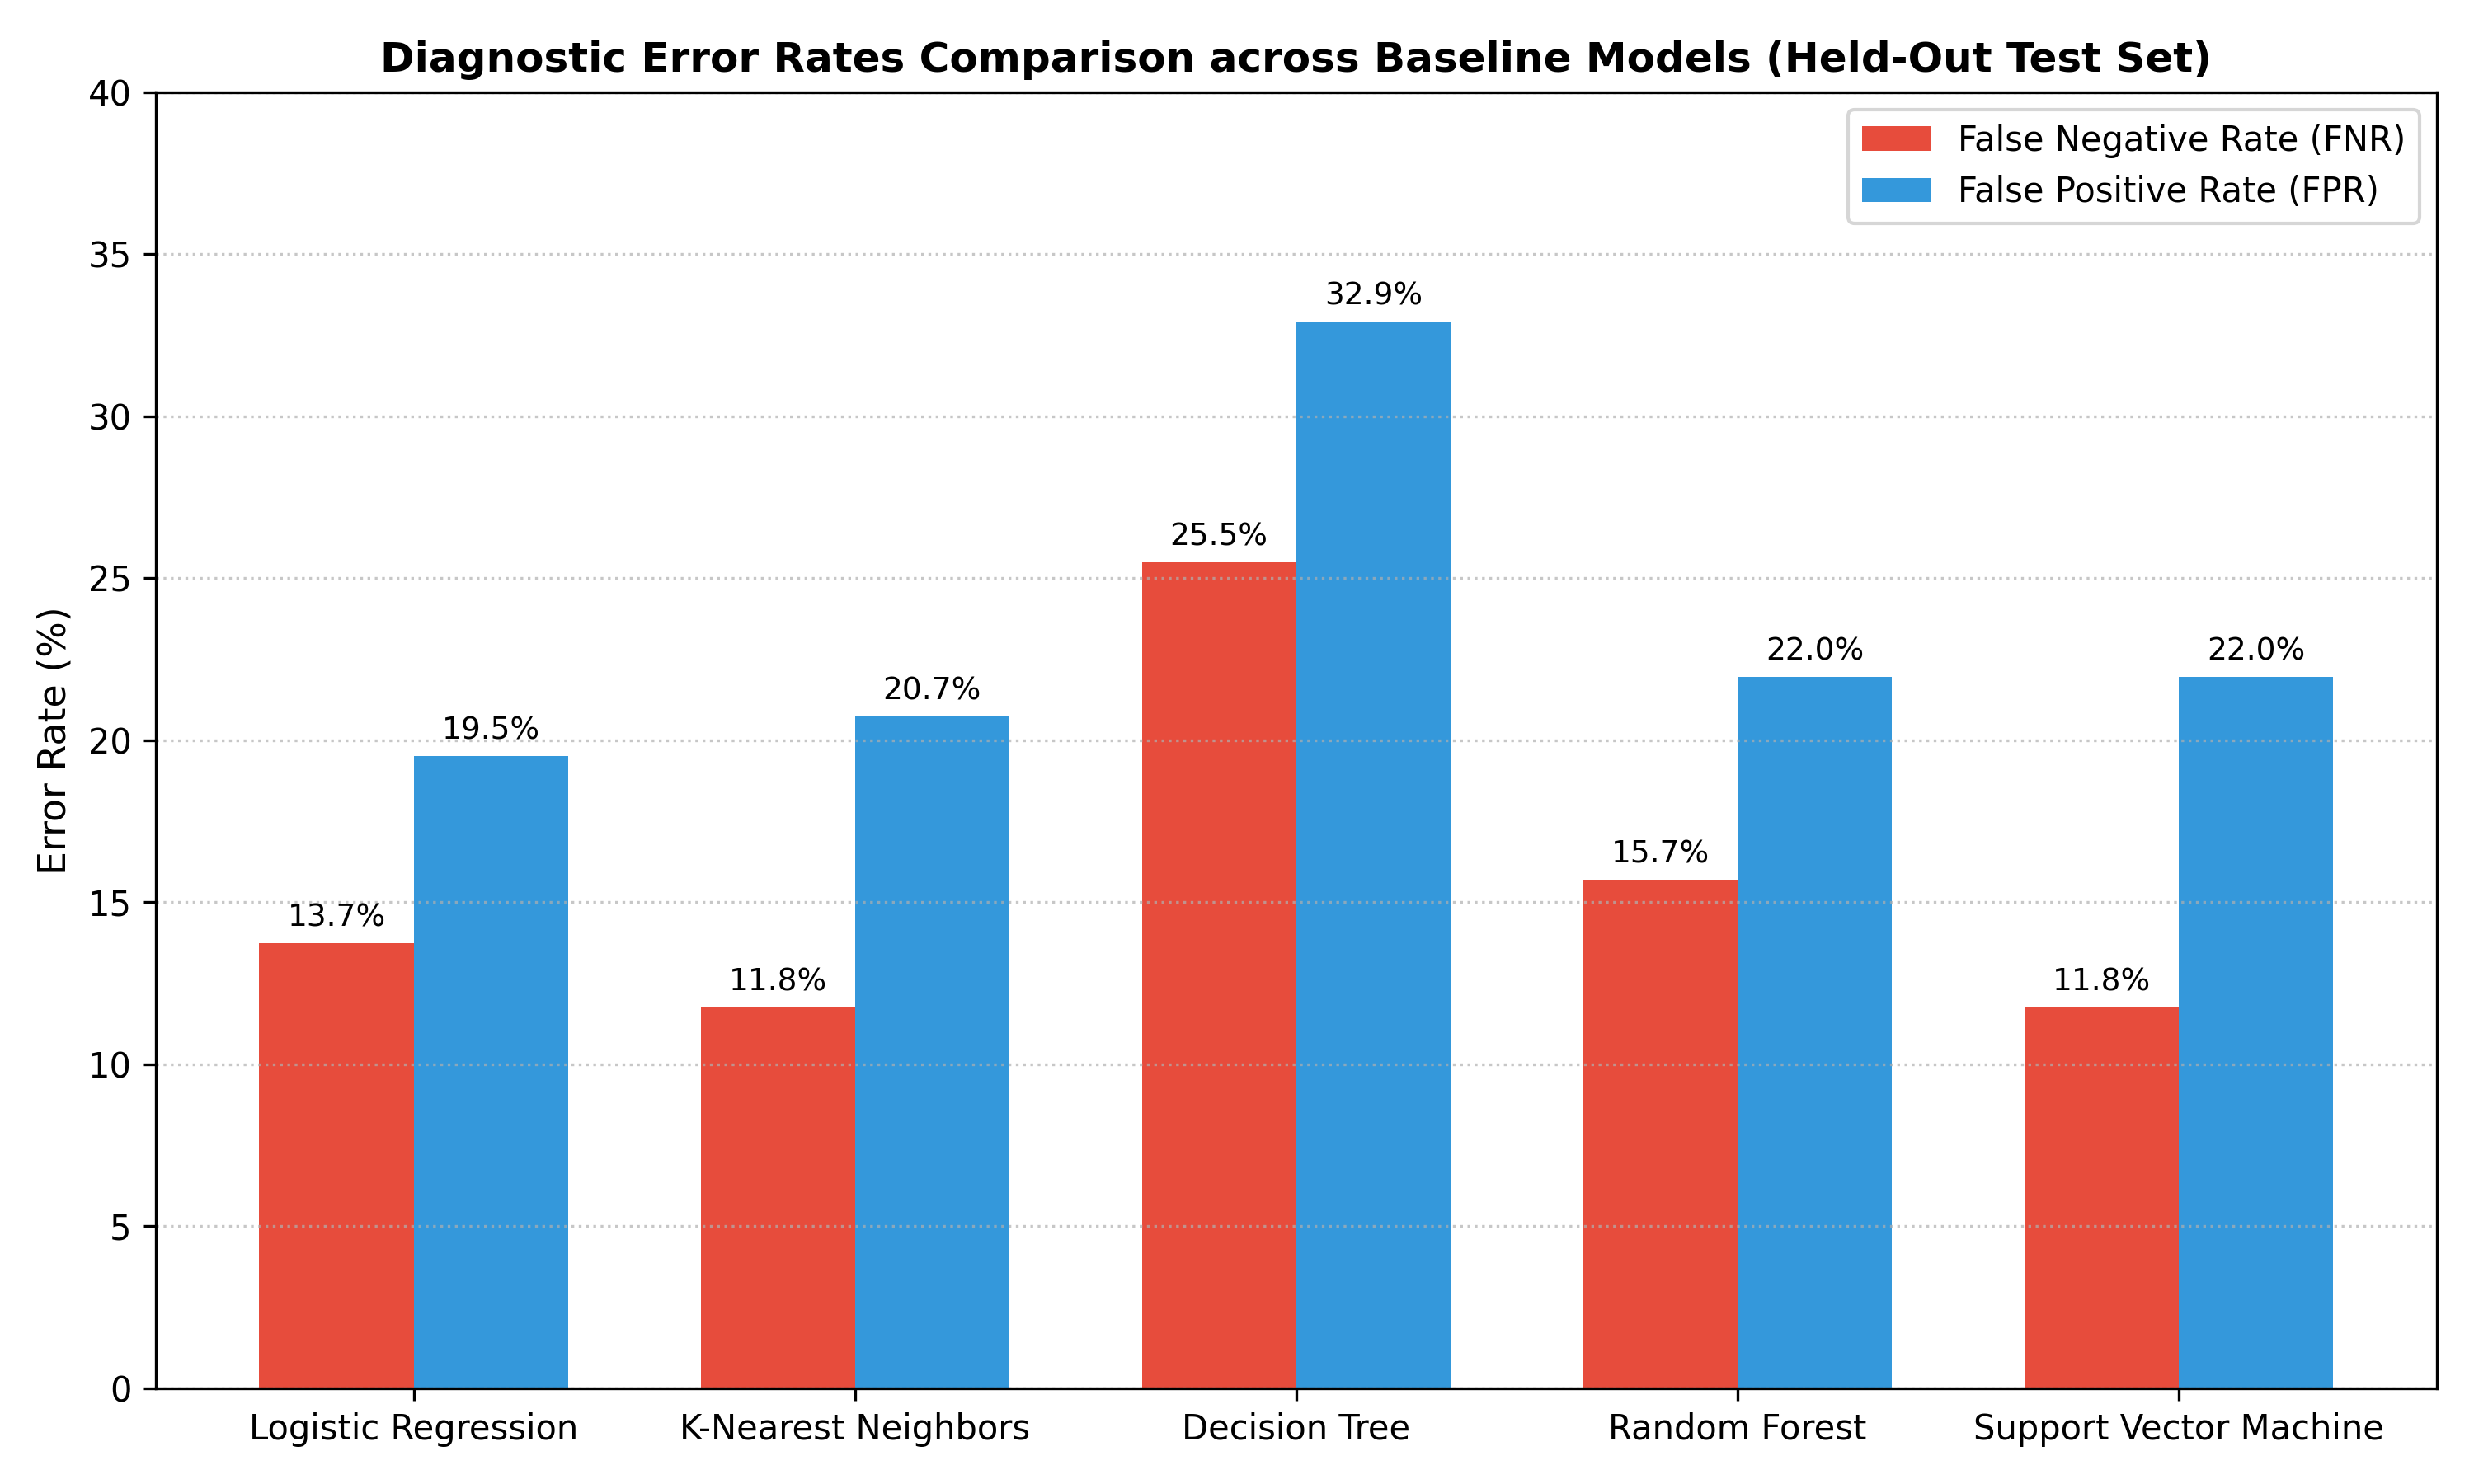

In [5]:
error_img = FIGURES_DIR / "model_error_rates.png"
if error_img.exists():
    display(Image(filename=str(error_img)))


### 2. Metric Comparisons: Sensitivity, Specificity, FNR, & FPR
- **Sensitivity / Recall Comparison:** KNN ($88.24\%$) = Support Vector Machine ($88.24\%$, $12$ FNs) > Logistic Regression ($86.27\%$, $14$ FNs) > Random Forest ($84.31\%$, $16$ FNs) > Decision Tree ($74.51\%$, $26$ FNs).
- **Specificity Comparison:** Logistic Regression ($80.49\%$, $16$ FPs) > KNN ($79.27\%$, $17$ FPs) > Support Vector Machine ($78.05\%$, $18$ FPs) = Random Forest ($78.05\%$, $18$ FPs) > Decision Tree ($67.07\%$, $27$ FPs).
- **False Negative Rate (FNR) Comparison:** KNN ($11.76\%$) = SVM ($11.76\%$) < Logistic Regression ($13.73\%$) < Random Forest ($15.69\%$) < Decision Tree ($25.49\%$).
- **False Positive Rate (FPR) Comparison:** Logistic Regression ($19.51\%$) < KNN ($20.73\%$) < Random Forest ($21.95\%$) = SVM ($21.95\%$) < Decision Tree ($32.93\%$).

### 3. Test vs Cross-Validation Generalization Analysis
We evaluate generalization performance gaps ($	ext{Test Metric} - 	ext{CV Metric Mean}$) across Accuracy, F1-Score, and ROC-AUC.


In [6]:
gen_df = analyze_cv_vs_test(results_df)
gen_df


,Model,Test_Accuracy,CV_Accuracy_Mean,Accuracy_Gap,Test_F1,CV_F1_Mean,F1_Gap,Test_ROC_AUC,CV_ROC_AUC_Mean,ROC_AUC_Gap
0,Logistic Regression,0.836957,0.816103,0.020854,0.854369,0.836922,0.017447,0.927786,0.879220,0.048566
1,K-Nearest Neighbors,0.842391,0.798369,0.044022,0.861244,0.827502,0.033742,0.899809,0.841092,0.058717
2,Decision Tree,0.711957,0.707129,0.004828,0.741463,0.732259,0.009205,0.707915,0.704748,0.003167
3,Random Forest,0.815217,0.806579,0.008638,0.834951,0.829020,0.005931,0.911227,0.857835,0.053392
4,Support Vector Machine,0.836957,0.810642,0.026314,0.857143,0.834702,0.022440,0.911406,0.866734,0.044672


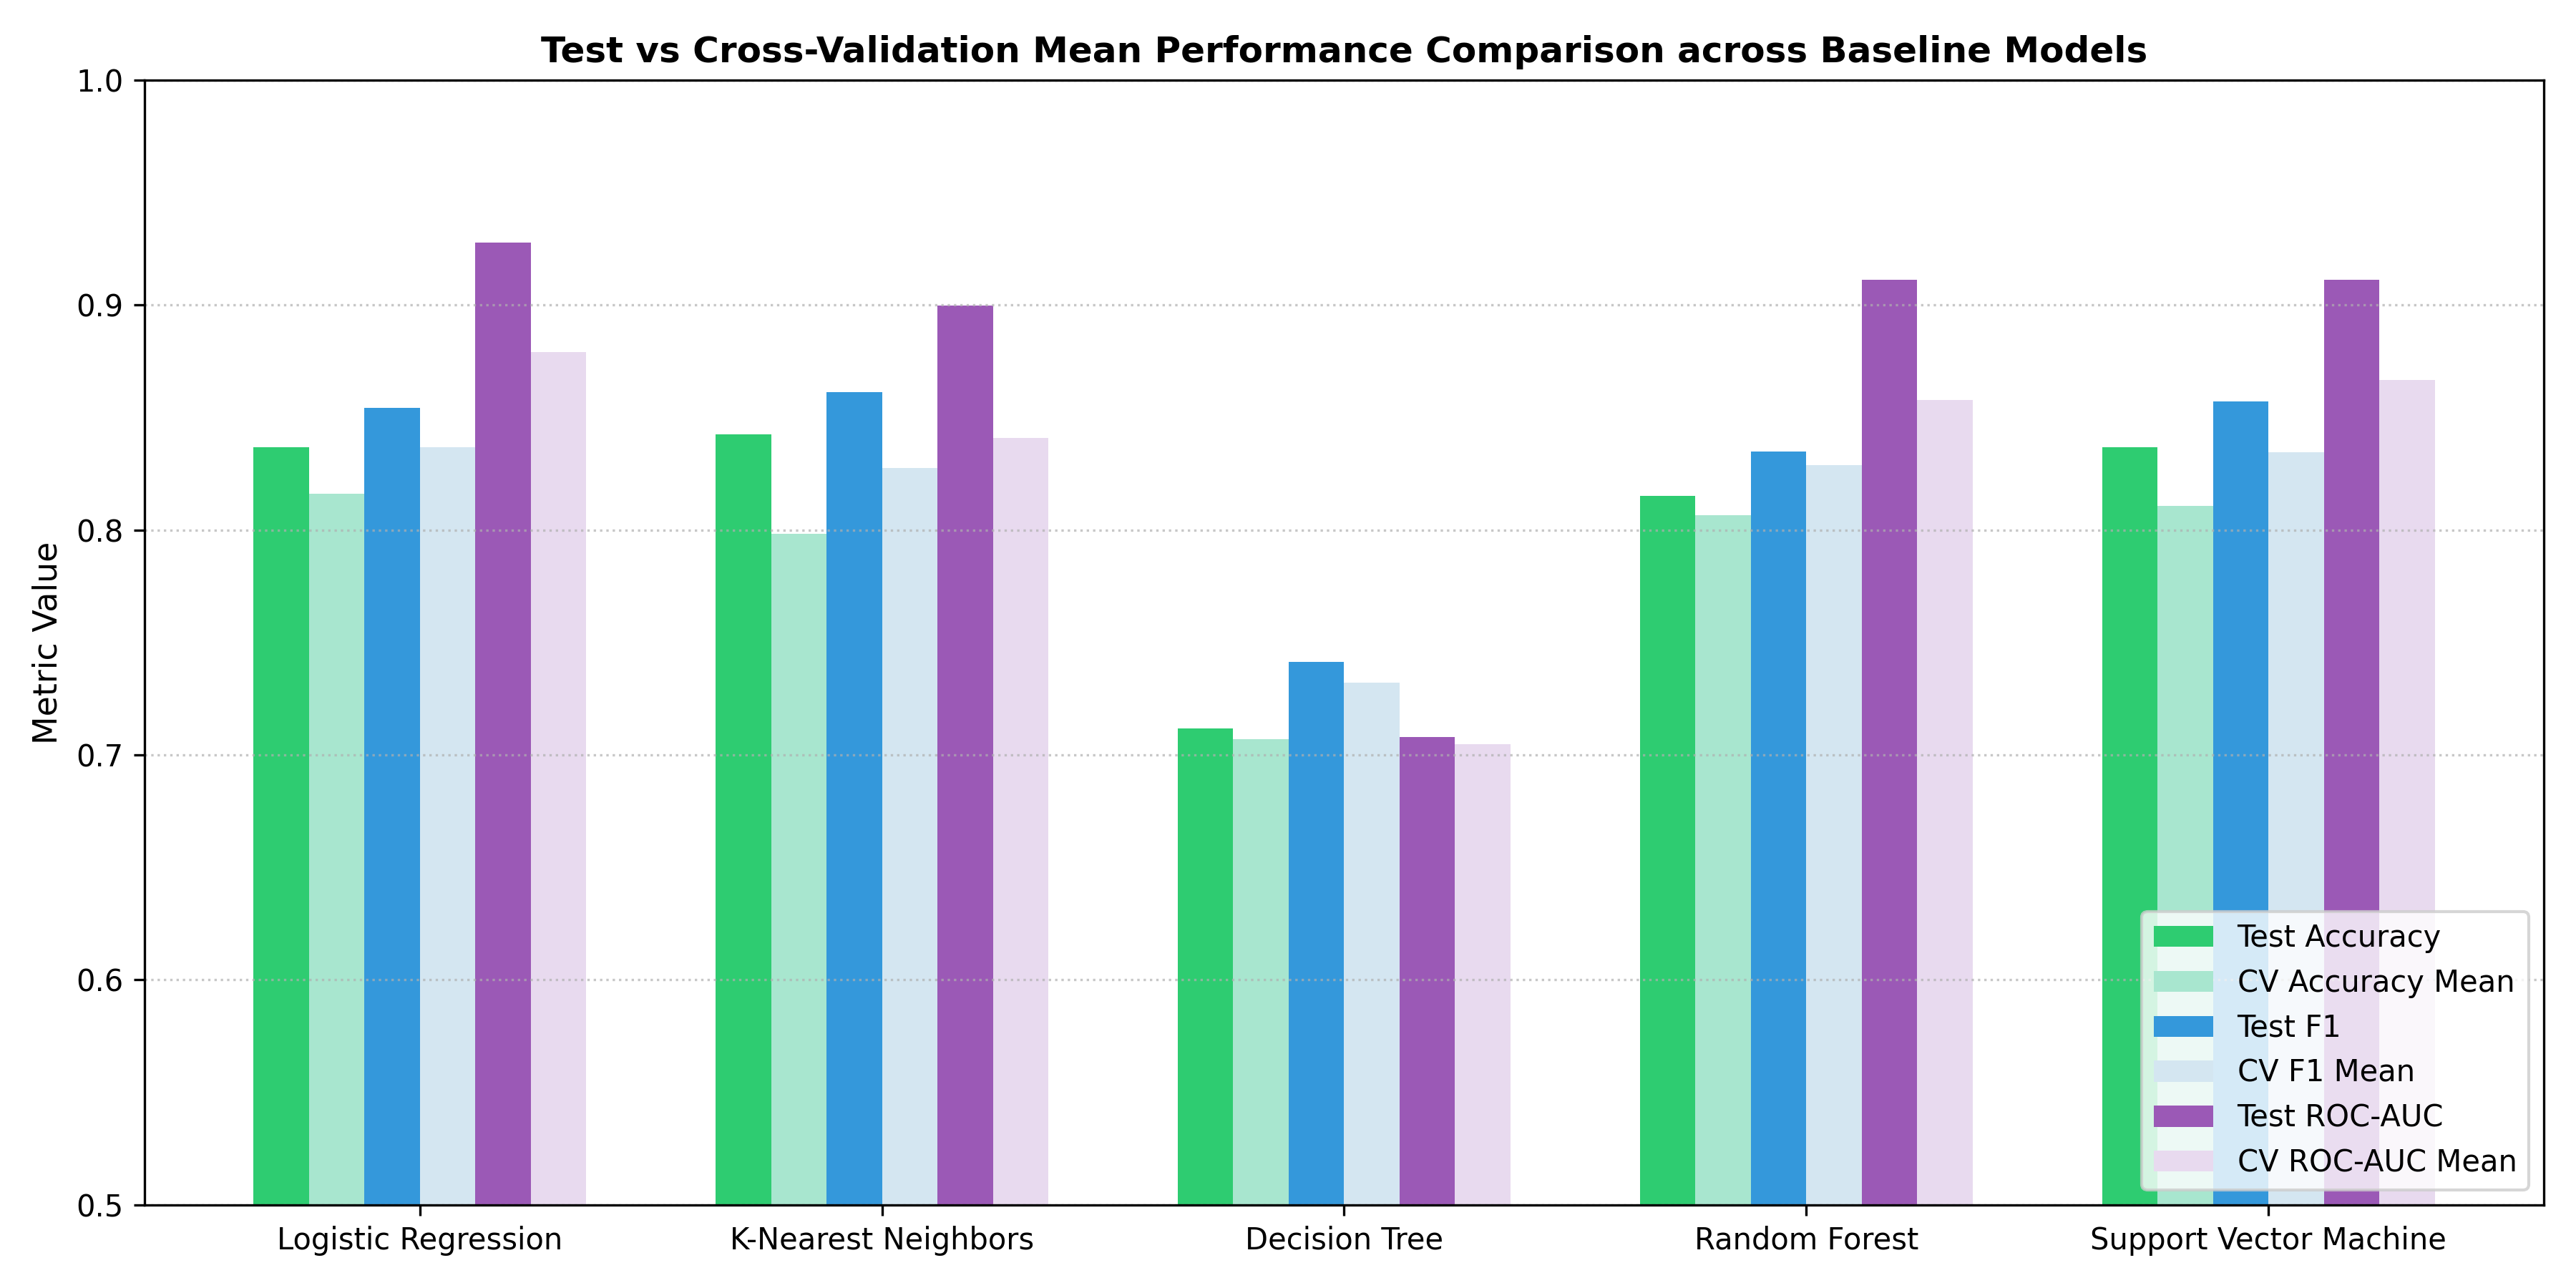

In [7]:
gen_img = FIGURES_DIR / "test_vs_cv_performance.png"
if gen_img.exists():
    display(Image(filename=str(gen_img)))


### 4. Generalization Discussion & Limitations
> **METHODOLOGICAL NOTE ON GENERALIZATION:** The difference between held-out test performance and cross-validation mean provides a useful comparison of observed performance across evaluation procedures, but these gaps alone do not establish overfitting.

- **Accuracy Gap ($	ext{Test} - 	ext{CV Mean}$):** Logistic Regression ($+2.09\%$), Support Vector Machine ($+2.63\%$), Random Forest ($+0.86\%$), Decision Tree ($+0.48\%$), K-Nearest Neighbors ($+4.40\%$).
- **F1-Score Gap:** Logistic Regression ($+1.74\%$), Support Vector Machine ($+2.24\%$), Random Forest ($+0.59\%$), Decision Tree ($+0.92\%$), K-Nearest Neighbors ($+3.37\%$).
- **ROC-AUC Gap:** Logistic Regression ($+4.86\%$), Support Vector Machine ($+4.47\%$), Random Forest ($+5.34\%$), Decision Tree ($+0.32\%$), K-Nearest Neighbors ($+5.87\%$).

**Limitations of Error & Generalization Analysis:**
1. **Single Train/Test Split:** Evaluated on a single 80/20 stratified split ($184$ test observations), resulting in sample variance for point estimates.
2. **Default Hyperparameters:** Baseline models were evaluated with default parameter settings; hyperparameter optimization was not performed.
3. **Clinical Scope:** Metrics evaluate statistical performance on tabular research data and do not establish clinical efficacy or diagnostic validity.


## 7. Logistic Regression Coefficients
Extract log-odds coefficients for transformed features from the fitted Logistic Regression pipeline.

> **NON-CAUSAL INTERPRETATION & METHODOLOGICAL NOTE:**
> The Logistic Regression coefficients indicate the direction and magnitude of association of each transformed feature with the model's predicted log-odds of class 1. Because all observed categorical levels are one-hot encoded, categorical coefficient interpretation should be treated cautiously and should not be interpreted as a simple comparison against an omitted reference category.


In [8]:
log_df = extract_logistic_coefficients(fitted_pipelines["Logistic Regression"])
log_df.head(15)


,Feature,Coefficient,Absolute_Coefficient,Direction
0,cat__cp_asymptomatic,0.967148,0.967148,Positive
1,bool__exang,0.939466,0.939466,Positive
2,cat__cp_typical angina,-0.724826,0.724826,Negative
3,cat__sex_Female,-0.653151,0.653151,Negative
4,cat__sex_Male,0.644142,0.644142,Positive
5,num__missingindicator_chol,0.556455,0.556455,Positive
6,num__oldpeak,0.528254,0.528254,Positive
7,bool__fbs,0.407067,0.407067,Positive
8,num__thalch,-0.338383,0.338383,Negative
9,num__age,0.280265,0.280265,Positive


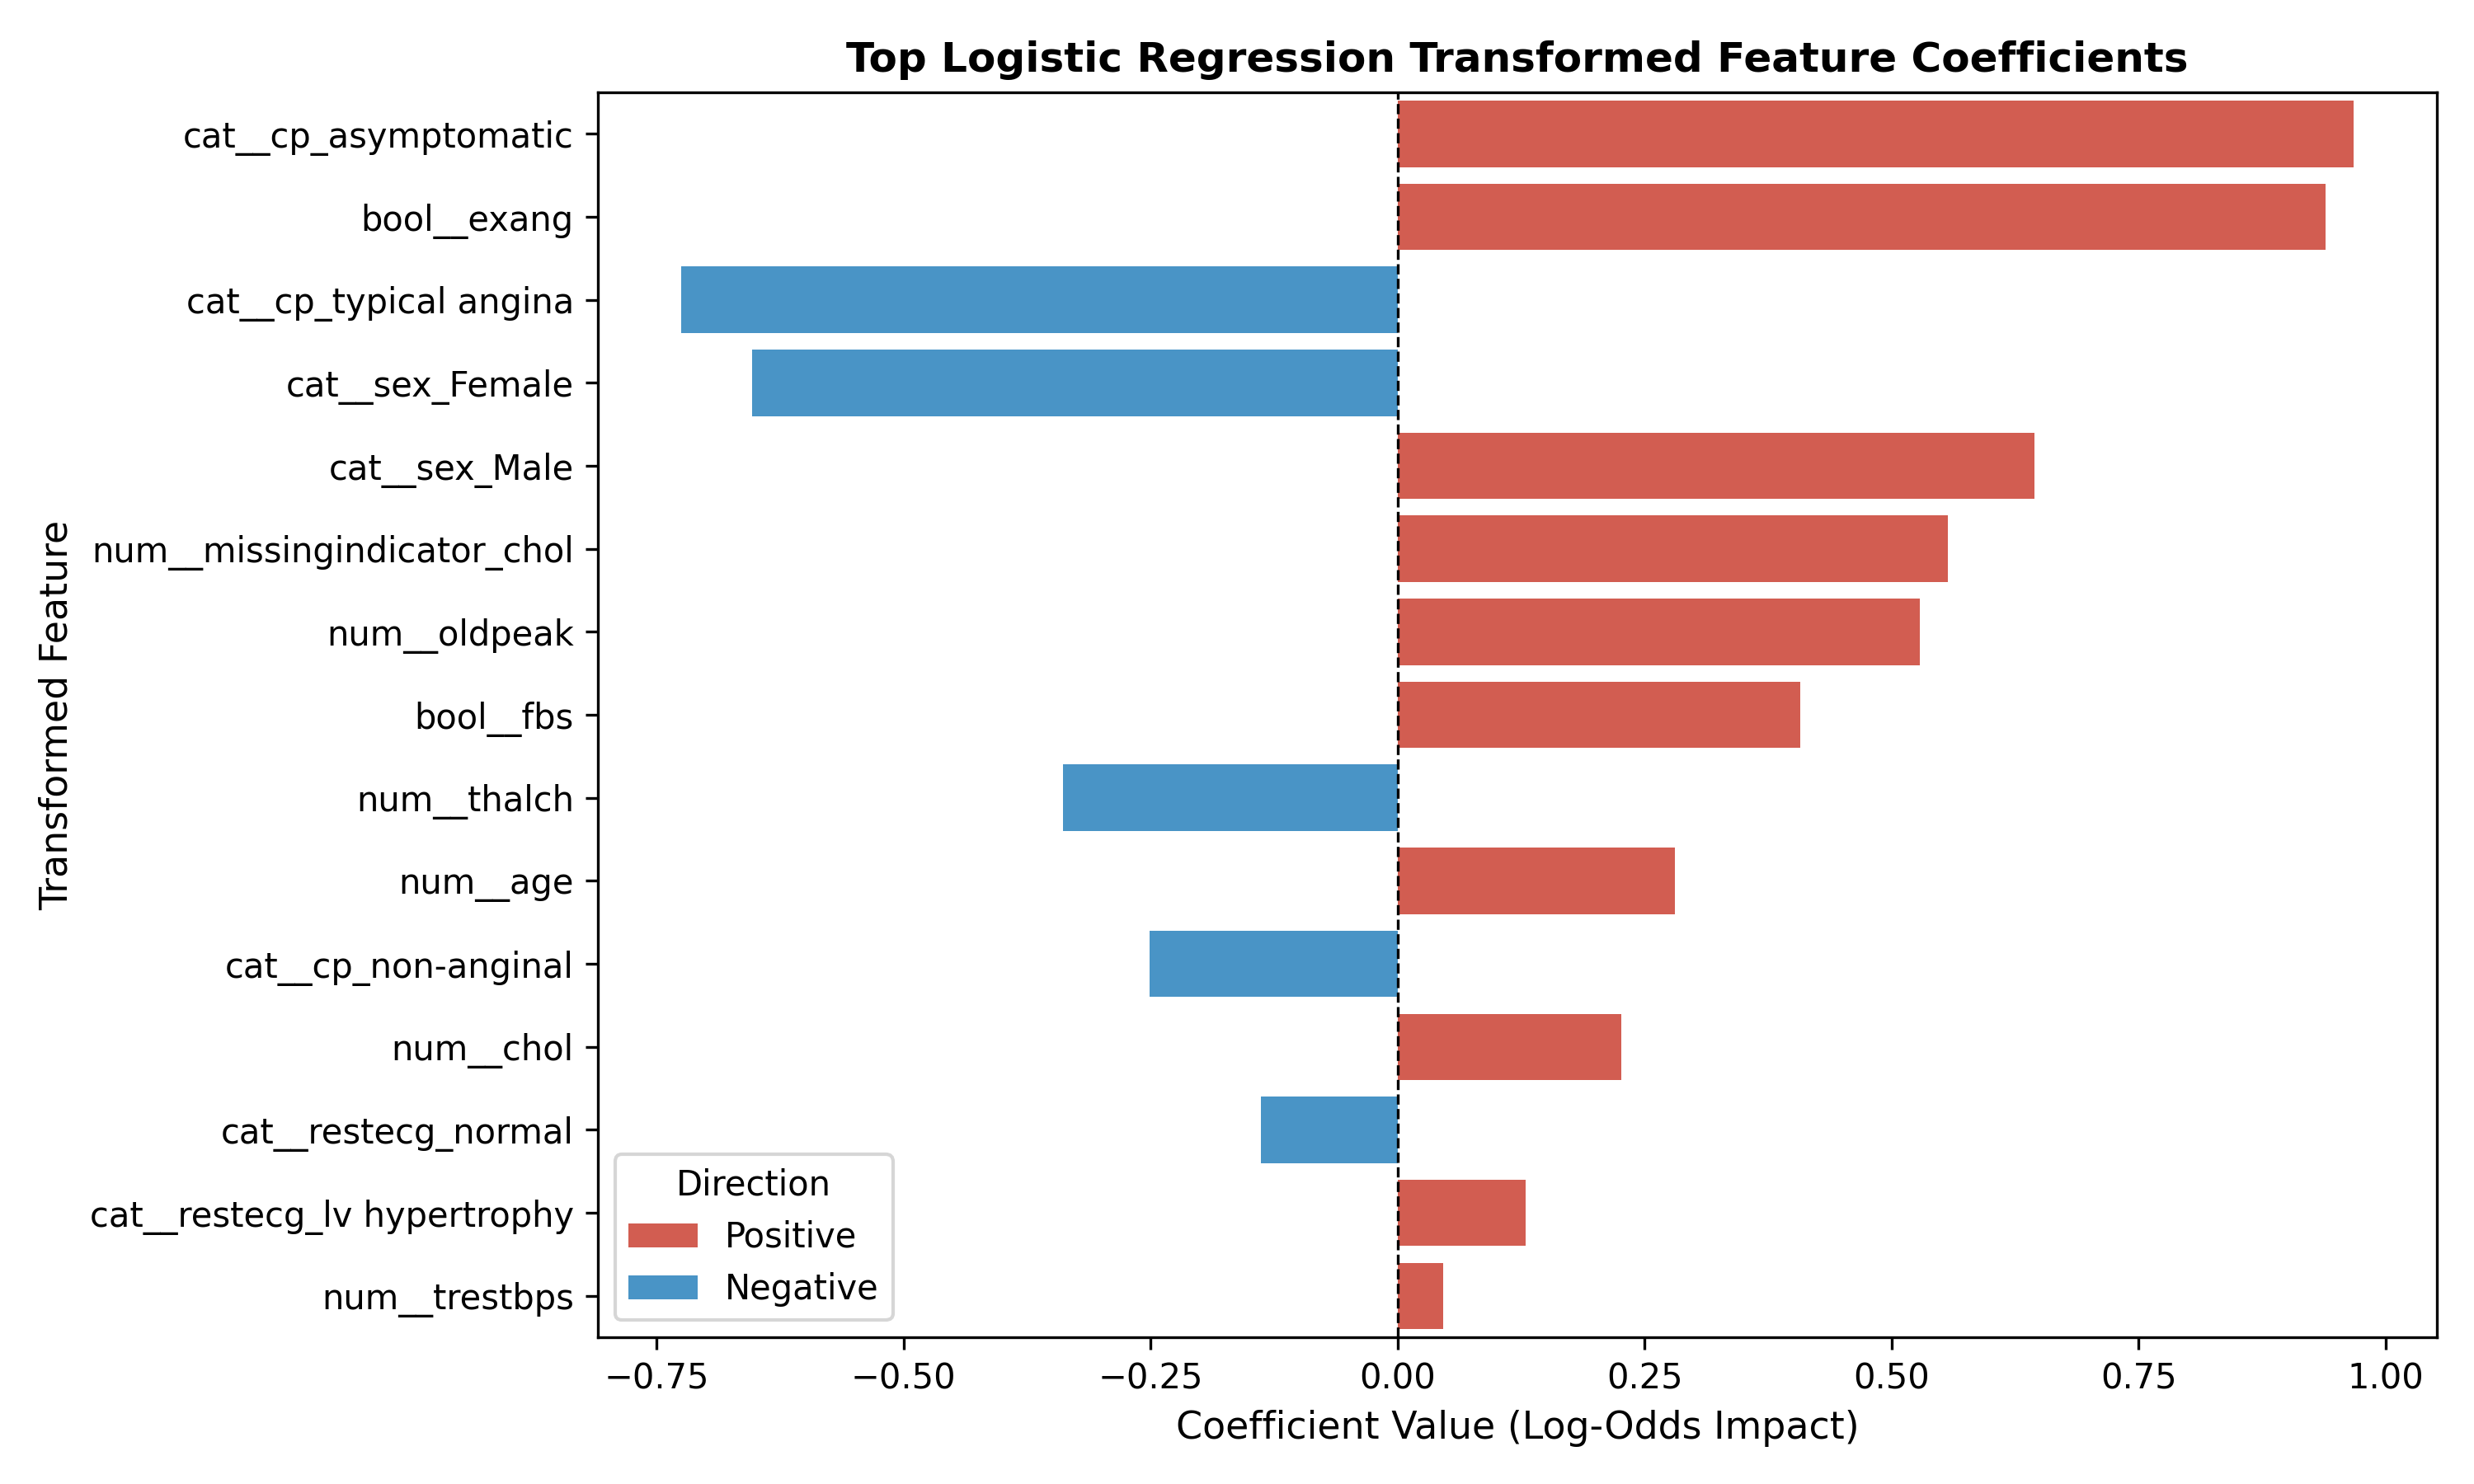

In [9]:
log_img = FIGURES_DIR / "logistic_regression_coefficients.png"
if log_img.exists():
    display(Image(filename=str(log_img)))


## 8. Random Forest Feature Importance
Extract Gini impurity feature importances from the fitted Random Forest pipeline.

> **NON-CAUSAL INTERPRETATION:**
> Random Forest feature importance reflects the feature's contribution to the fitted tree ensemble and does not establish causality.


In [10]:
rf_df = extract_tree_feature_importance(fitted_pipelines["Random Forest"])
rf_df.head(15)


,Feature,Importance
0,num__thalch,0.137115
1,num__age,0.128824
2,cat__cp_asymptomatic,0.121956
3,num__oldpeak,0.115413
4,num__chol,0.112091
5,num__trestbps,0.088479
6,bool__exang,0.068816
7,cat__cp_typical angina,0.045072
8,num__missingindicator_chol,0.044554
9,cat__sex_Female,0.029086


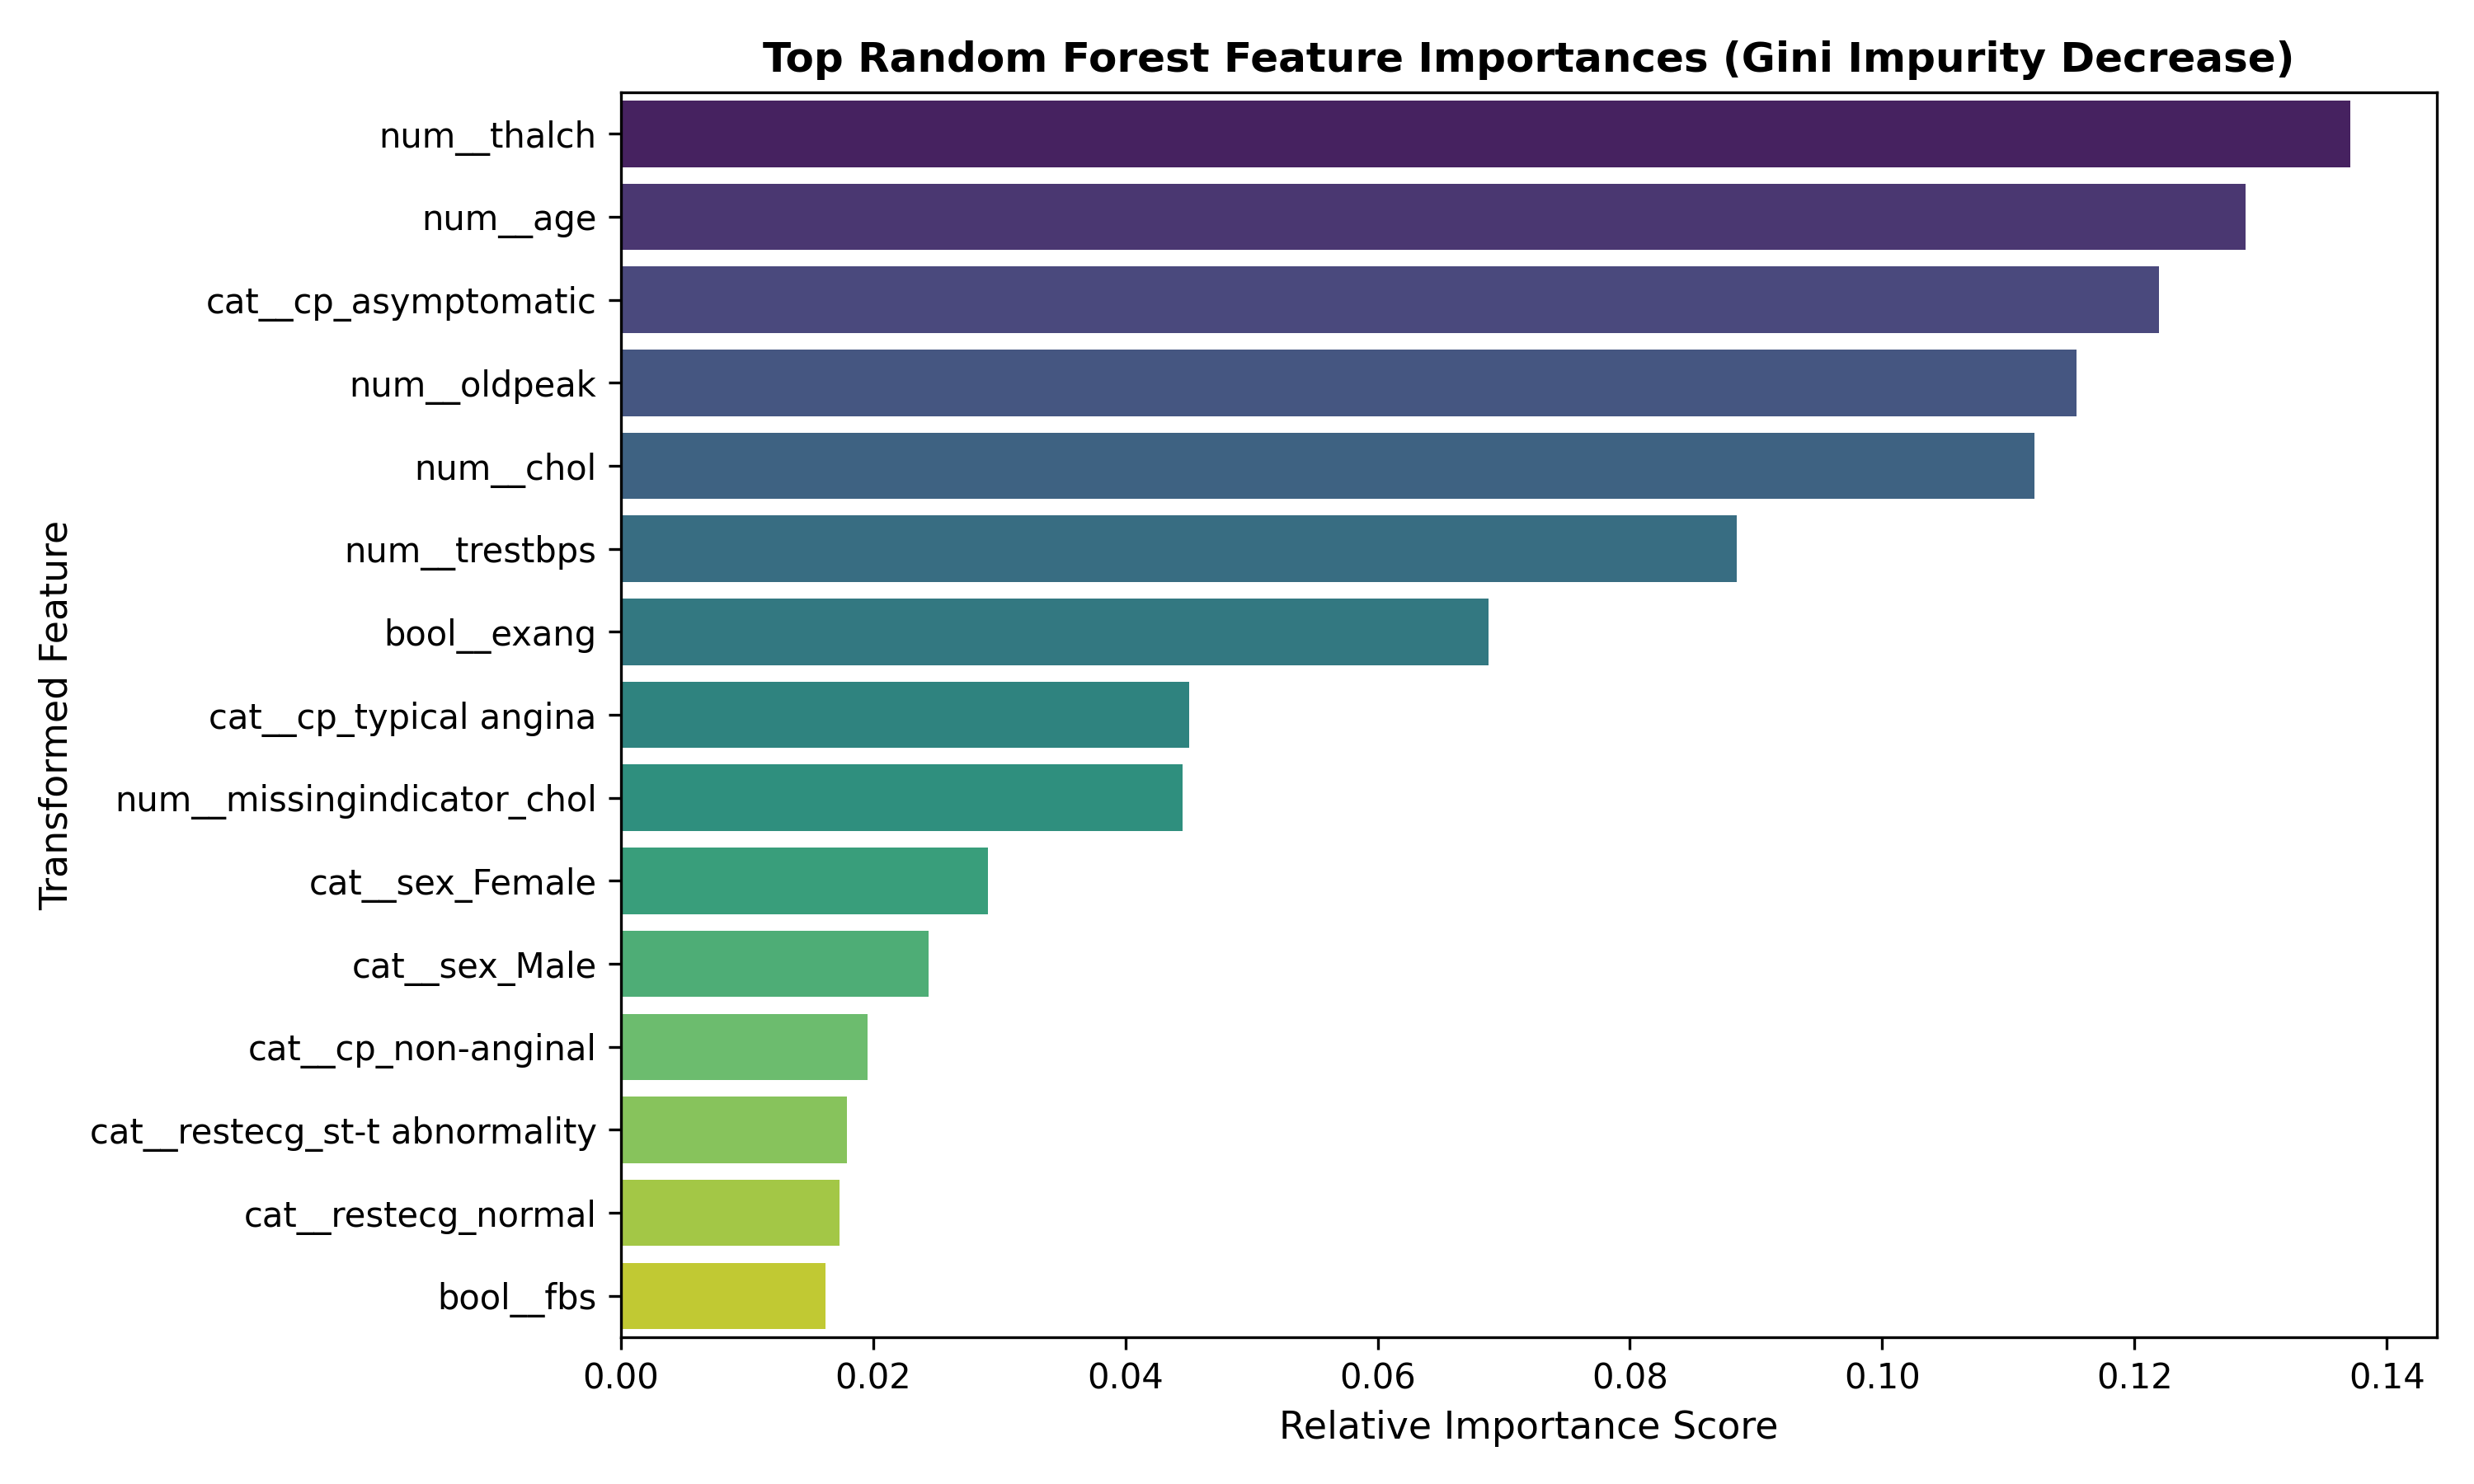

In [11]:
rf_img = FIGURES_DIR / "random_forest_feature_importance.png"
if rf_img.exists():
    display(Image(filename=str(rf_img)))


## 9. Compare Feature Importance
Identify overlapping top-10 features between linear log-odds coefficients and tree Gini importances.


In [12]:
comp_df = compare_feature_importance(log_df, rf_df, top_n=10)
comp_df


,Feature,Logistic_Absolute_Coefficient,Random_Forest_Importance,Appears_Important_Logistic,Appears_Important_RF,Appears_Important_Both
0,cat__cp_asymptomatic,0.967148,0.121956,True,True,True
1,bool__exang,0.939466,0.068816,True,True,True
2,cat__cp_typical angina,0.724826,0.045072,True,True,True
3,cat__sex_Female,0.653151,0.029086,True,True,True
4,num__missingindicator_chol,0.556455,0.044554,True,True,True
5,num__oldpeak,0.528254,0.115413,True,True,True
6,num__thalch,0.338383,0.137115,True,True,True
7,num__age,0.280265,0.128824,True,True,True
8,cat__sex_Male,0.644142,0.024433,True,False,False
9,bool__fbs,0.407067,0.016245,True,False,False


## 10. Model Interpretability Discussion

### Methodological Note on One-Hot Encoding & Causality
The Logistic Regression coefficients indicate the direction and magnitude of association of each transformed feature with the model's predicted log-odds of class 1. Because all observed categorical levels are one-hot encoded, categorical coefficient interpretation should be treated cautiously and should not be interpreted as a simple comparison against an omitted reference category.

Random Forest feature importance reflects the feature's contribution to the fitted tree ensemble and does not establish causality.

### Feature Overlap Observations
- **`cat__cp_asymptomatic`**: Among the transformed features, this feature has a relatively large absolute coefficient in the fitted Logistic Regression model and high model feature importance in Random Forest.
- **`bool__exang`**: Exercise-induced angina (`bool__exang`): Among the transformed features, this feature has a relatively large absolute coefficient in the fitted Logistic Regression model and high model feature importance in Random Forest.
- **`num__oldpeak`**: ST depression induced by exercise (`num__oldpeak`): Among the transformed features, this feature has a relatively large absolute coefficient in the fitted Logistic Regression model and high model feature importance in Random Forest.
- **`num__thalch`**: Maximum heart rate achieved (`num__thalch`): Among the transformed features, this feature has a relatively large absolute coefficient in the fitted Logistic Regression model and the highest model feature importance in Random Forest.


## Baseline Model Selection

### 1. Final Multi-Criteria Baseline Comparison Table

| Model | Test ROC-AUC | Test Acc | Test F1 | Test Recall | Test Spec | CV Acc Mean | CV ROC-AUC | FNR | FPR | Interpretability |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Logistic Regression** | **$0.9278$** | $83.70\%$ | $85.44\%$ | $86.27\%$ | **$80.49\%$** | **$81.61\%$** | **$0.8792$** | $13.73\%$ | **$19.51\%$** | High (Log-Odds) |
| **Support Vector Machine** | $0.9114$ | $83.70\%$ | $85.71\%$ | **$88.24\%$** | $78.05\%$ | $81.06\%$ | $0.8667$ | **$11.76\%$** | $21.95\%$ | Moderate (Kernel) |
| **K-Nearest Neighbors** | $0.8998$ | **$84.24\%$** | **$86.12\%$** | **$88.24\%$** | $79.27\%$ | $79.84\%$ | $0.8411$ | **$11.76\%$** | $20.73\%$ | Low (Non-parametric) |
| **Random Forest** | $0.9112$ | $81.52\%$ | $83.50\%$ | $84.31\%$ | $78.05\%$ | $80.66\%$ | $0.8578$ | $15.69\%$ | $21.95\%$ | Moderate (Gini Impurity) |
| **Decision Tree** | $0.7079$ | $71.20\%$ | $74.15\%$ | $74.51\%$ | $67.07\%$ | $70.71\%$ | $0.7047$ | $25.49\%$ | $32.93\%$ | High (Tree Structure) |

### 2. Primary Candidate Model: **Logistic Regression**
- **Justification:** Highest test discrimination (ROC-AUC = **$0.9278$**), highest CV mean accuracy (**$81.61\% \pm 4.46\%$**), highest test specificity (**$80.49\%$**), lowest FPR (**$19.51\%$**), and direct mathematical log-odds coefficient interpretability.
- **Phase 6 Readiness:** Excellent baseline for hyperparameter tuning (`C`, `penalty`, `solver`), probability calibration, and decision threshold optimization.

### 3. Secondary Candidate Model: **Support Vector Machine (SVC)**
- **Justification:** Tied-highest test sensitivity (**$88.24\%$**, $12$ FNs), low FNR (**$11.76\%$**), strong test ROC-AUC (**$0.9114$**), high test accuracy ($83.70\%$), and strong CV performance ($81.06\% \pm 4.06\%$).
- **Phase 6 Readiness:** Robust non-linear candidate for Phase 6 hyperparameter tuning (`C`, `gamma`, `kernel`).

### 4. Excluded Baseline Models
- **K-Nearest Neighbors:** Strong test metrics ($84.24\%$ Acc, $88.24\%$ Recall), but lower CV mean accuracy ($79.84\%$), larger ROC-AUC generalization gap ($+5.87\%$), and lacks parametric global model interpretability.
- **Random Forest:** Solid test ROC-AUC ($0.9112$), but lower baseline test accuracy ($81.52\%$) and F1 ($83.50\%$) compared to Logistic Regression ($83.70\%$) and SVM ($83.70\%$).
- **Decision Tree:** Substantially lower test accuracy ($71.20\%$) and ROC-AUC ($0.7079$) due to single-tree variance and instability.

### 5. Multi-Criteria Selection Rationale
Candidate selection was conducted using a multi-criteria evidence-based framework without combining metrics into an arbitrary numerical weighted score.
- **Observed Performance Consistency:** Logistic Regression and SVM demonstrated the most consistent performance across cross-validation and held-out test evaluation.
- **Diagnostic Trade-offs:** Logistic Regression minimizes false positives ($19.51\%$ FPR), while SVM minimizes false negatives ($11.76\%$ FNR).

### 6. Limitations
1. **Sample Size:** 918 patient observations ($734$ train / $184$ test). Metric point estimates carry sampling variance.
2. **Default Parameters:** Baseline models were evaluated with standard default parameters.
3. **Research Scope:** Evaluated metrics reflect statistical performance on tabular research data and do not establish clinical efficacy or diagnostic validity.

### 7. Phase 6 Recommendation
- Advance **Logistic Regression** (Primary Candidate) and **Support Vector Machine** (Secondary Candidate) to Phase 6 for hyperparameter tuning (`GridSearchCV`), probability calibration, and threshold optimization.


In [13]:
# Generate Markdown Summary File
generate_model_selection_summary(results_df, gen_df, cm_df, comp_df)
print("Model Selection Summary saved to reports/model_selection_summary.md")


Model Selection Summary saved to reports/model_selection_summary.md


## 12. Limitations

1. **Sample Size:** 918 patient observations ($734$ training, $184$ testing). Small test sets increase metric variance.
2. **Default Hyperparameters:** Baseline models were evaluated with standard default parameters.
3. **Clinical Scope:** Risk estimates are derived from tabular clinical attributes for research purposes; they do not constitute a clinically validated diagnostic system.


## 13. Conclusion
In Phase 5:
1. Analyzed Logistic Regression coefficients and Random Forest feature importances.
2. Verified feature overlap (`cp_asymptomatic`, `exang`, `oldpeak`, `thalch`).
3. Computed confusion matrix metrics (Recall, Specificity, FNR, FPR).
4. Selected **Logistic Regression** as the **Primary Candidate Model** and **Support Vector Machine (SVC)** as the **Secondary Candidate Model**.
5. Generated `reports/model_selection_summary.md` and required reports CSV files.
